In [1]:
import ui
import construct
import ifc

import ui.comms

from system_config import *
from construction_config import *

import construct.analysis as analysis
# fov_plotter = analysis.FOVPlotter()
# fov_plotter.plot_camera_fov_at_location(packet['coordinates'][0],packet['coordinates'][1],packet['coordinates'][2],FOV_horizontal,FOV_vertical,90)  
 
from ui.mobility import moveJ, moveL, translate, set_orientation, gripper_width
# from construct.marker_pose import align_with_random_part
from construct.construction import rotation_matrix_to_vector
import ui.MarkerDetectionLocalization as mdl
# import time
# ui.show_project_structure()

HERE!!!

In [6]:
import pickle
import os

# # Define the path
# load_dir = '/home/avi/Desktop/robomason/_workingdata/Development'

# # Load each pickle file
# with open(os.path.join(load_dir, 'reassembly_data.pkl'), 'rb') as f:
#     reassembly_data = pickle.load(f)

options_reassembly = {
    "trajectory_analysis": True,
    "hazard_analysis": False,
    "detection_analysis": False,
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis":True,
    "data": reassembly_data
}


analyzed_results_reassembly = ui.analyze_trajectory(options_reassembly,"reassembly")
path_reassembly = ui.save_results(analyzed_results_reassembly, reassembly_data,'rect') 

reassembly_file = ui.create_construction_summary_html(path_reassembly)
ui.open_html_in_browser(reassembly_file)

[INFO] Starting trajectory analysis...
[INFO] Summarizing trajectory metrics...
[INFO] Plotting velocity and acceleration...
[INFO] Trajectory analysis completed.
[INFO] Performing segment-wise analysis...
scanning_site
bathroom_module_1
Wall_1
Floor_1
bathroom_module_2
Wall_2
Floor_2
bathroom_module_3
[INFO] Segment analysis completed.
[INFO] Plotting worker positions...
[INFO] Worker plotting completed.
[INFO] Plotting full trajectory run...
[INFO] Full run plot completed.
[INFO] All requested analyses completed.
Results saved in /home/avi/Desktop/robomason/_workingdata/_reconstructionruns/reconstruction_run_02


[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Subscribed to topic: /image
Robot data listener started on tcp://127.0.0.1:5560...
Listening for tracking messages...
[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Subscribed to topic: /image


{'coordinates': [0.232, -0.574, 0.419],
 'element': None,
 'state': None,
 'joints': [1.7351632118225098,
  -1.3019434374621888,
  1.4464886824237269,
  -1.743998189965719,
  -1.5509942213641565,
  0.24133333563804626],
 'orientation': [[-0.9969715749031063,
   0.07491400314170583,
   -0.020870337048175047],
  [0.07542321852878346, 0.9968435476632088, -0.024784664391264484],
  [0.018947742397956397, -0.026283713883557762, -0.9994749368756117]],
 'worker spotted': False,
 'timestamp_send': 1744360964.0007987,
 'obstacle_maneuver': False}

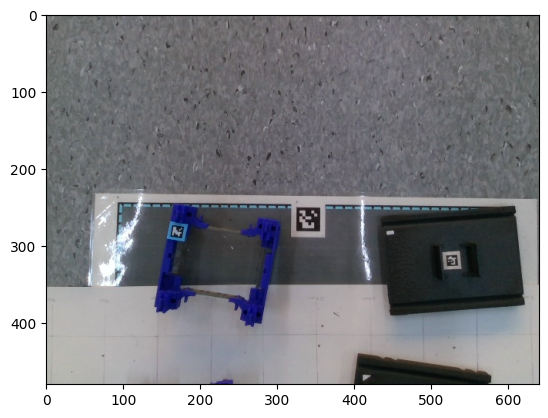

In [2]:
framehandler = ui.initializeUI()
packet = ui.comms.get_current_packet()
packet

In [ ]:
# Assembly 
ui.comms.refresh_tracking_packets() #Refresh stored data
script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v1.ifc", "--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

# idx = construct.check_continue()
idx = 0

item_list, block_list, pl_pos = construct.perform_construction(IFC_sorted, framehandler, idx,use_stub= False)
assembly_data = ui.load_data(10) 

Performing site scan (real routine)
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Searching for Foundation
The item is here:
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
Debug: Calculated angle: 0
Initiating bathroom routine for associated element.
We should now place a colored toilet!
Red found = True
Blue found = True
Searching for Wall
The item is here:
We can't see the correct marker!
Unable to find fiducial marker. Please check the setup.
Searching for Floor
The item is here:
Unable to find fiducial marker. Please check the setup.
Initiating bathroom routine for associated element.
We should now place a colored toilet!
Red found = True
Blue found = True
Placing toilet on floor
Second bathroom
Searching for Wall
The item is here:
Unable to find fiducial marker. Please check the setup.
Searching for Floor
The 

In [ ]:
# Disassembly 
ui.comms.refresh_tracking_packets() #Refresh stored data


construct.disassembly(item_list, pl_pos, block_list, framehandler)
disassembly_data = ui.load_data(10)

In [3]:
# Reassembly 
ui.comms.refresh_tracking_packets() #Refresh stored data

#Assembly 2
script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v2.ifc","--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

# idx = construct.check_continue()
idx = 0

item_list, block_list, pl_pos = construct.perform_reconstruction(IFC_sorted,framehandler, idx)
reassembly_data = ui.load_data(10)

Using stub file for site scan
Unable to find fiducial marker. Please check the setup.
Skipping placement for Foundation.
Initiating bathroom routine for associated element.
We should now place a colored toilet!
Red found = True
Blue found = True
Searching for Wall
The item is here:
Unable to find fiducial marker. Please check the setup.
Searching for Floor
The item is here:
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct mark

In [4]:
# import pickle
# import os

# save_dir = '/home/avi/Desktop/robomason/_workingdata/Development'

# # Save variables only if they exist and are not None
# if 'assembly_data' in locals() and assembly_data is not None:
#     with open(os.path.join(save_dir, 'assembly_data.pkl'), 'wb') as f:
#         pickle.dump(assembly_data, f)

# if 'disassembly_data' in locals() and disassembly_data is not None:
#     with open(os.path.join(save_dir, 'disassembly_data.pkl'), 'wb') as f:
#         pickle.dump(disassembly_data, f)

# if 'reassembly_data' in locals() and reassembly_data is not None:
#     with open(os.path.join(save_dir, 'reassembly_data.pkl'), 'wb') as f:
#         pickle.dump(reassembly_data, f)

# print("Files saved successfully!")

############################################################################

# import pickle
# import os

# # Define the path
# load_dir = '/home/avi/Desktop/robomason/_workingdata/Development'

# Load each pickle file
# with open(os.path.join(load_dir, 'assembly_data.pkl'), 'rb') as f:
#     assembly_data = pickle.load(f)

# with open(os.path.join(load_dir, 'disassembly_data.pkl'), 'rb') as f:
#     disassembly_data = pickle.load(f)

# with open(os.path.join(load_dir, 'reassembly_data.pkl'), 'rb') as f:
#     reassembly_data = pickle.load(f)

Files saved successfully!


In [ ]:
import pickle

current_data = "/home/avi/Desktop/robomason/_workingdata/Development/sample_raw_data.pkl"

# Load the pickle file
with open(current_data, 'rb') as f:
    current_data = pickle.load(f)

########################################################################################################

options = {
    "trajectory_analysis": True,
    "detection_analysis": True,
    "plot_full_run": True,
    "segment_analysis":True,
    "plot_workers":True,
    "data": current_data
}

analyzed_results = ui.analyze_trajectory(options)
path = ui.save_results(analyzed_results, current_data,'ct')

html_file = ui.create_construction_summary_html(path)
ui.open_html_in_browser(html_file)

In [ ]:
###################################################################################################
####################################### Casper's test blocks  #####################################
###################################################################################################


# #Close bottom pick up
# part_id = 8
# length_mark = 0.01
# x_offset = -0.0075
# y_offset = -0.065
# _z_level = 0.17
# _gripper_width = 70
# construct.pick_random_element(part_id, length_mark, x_offset, y_offset,_z_level, _gripper_width, framehandler)
# # gripper_width(100)

# #Ground level place (Closed bottom)
# z_level_ = 0.175
# rotation = 0
# construct.place_random_element(z_level_, rotation, framehandler)

# ###############################################################################################

# # #Open bottom pick up
# part_id = 9
# length_mark = 0.01
# x_offset = -0.0075
# y_offset = -0.065
# _z_level = 0.17
# _gripper_width = 70
# construct.pick_random_element(part_id, length_mark, x_offset, y_offset,_z_level, _gripper_width, framehandler)
# # gripper_width(100)

# #First level place (Open bottom)
# z_level_ = 0.198
# rotation = 0
# construct.place_random_element(z_level_, rotation, framehandler)

In [ ]:
###################################################################################################
####################################### Full size test blocks  ####################################
###################################################################################################

# #Close bottom pick up
# part_id = 10
# length_mark = 0.01
# x_offset = -0.0075
# y_offset = -0.065
# _z_level = 0.19
# _gripper_width = 70
# construct.pick_random_element(part_id, length_mark, x_offset, y_offset,_z_level, _gripper_width, framehandler)
# gripper_width(100)

# #Ground level place (Closed bottom)
# z_level_ = 0.198
# rotation = 0
# construct.place_random_element(z_level_, rotation, framehandler)

# ###############################################################################################

# # #Open bottom pick up
# # part_id = 10
# # length_mark = 0.01
# # x_offset = -0.0075
# # y_offset = -0.065
# # _z_level = 0.196
# # _gripper_width = 70
# # construct.pick_random_element(part_id, length_mark, x_offset, y_offset,_z_level, _gripper_width, framehandler)
# # # gripper_width(100)

# # #First level place (Open bottom)
# # z_level_ = 0.255
# # rotation = 0
# # construct.place_random_element(z_level_, rotation, framehandler)

In [ ]:
# %matplotlib inline
# fig_vel

In [ ]:
# import os
# import pickle

# # Define the save directory
# save_dir = "/home/avi/Desktop/robomason/_workingdata/Development"

# # Define file paths
# item_list_path = os.path.join(save_dir, "item_list.pkl")
# block_list_path = os.path.join(save_dir, "block_list.pkl")
# pl_pos_path = os.path.join(save_dir, "pl_pos.pkl")

# # Save data to pickle files
# with open(item_list_path, 'wb') as f:
#     pickle.dump(item_list, f)

# with open(block_list_path, 'wb') as f:
#     pickle.dump(block_list, f)

# with open(pl_pos_path, 'wb') as f:
#     pickle.dump(pl_pos, f)

# print("Files saved successfully!.")

#################################################################################################

# import pickle
# import os

# save_dir = "/home/avi/Desktop/robomason/_workingdata/Development"

# item_list_path = os.path.join(save_dir, "item_list.pkl")
# block_list_path = os.path.join(save_dir, "block_list.pkl")
# pl_pos_path = os.path.join(save_dir, "pl_pos.pkl")

# # Load the pickle files
# with open(item_list_path, 'rb') as f:
#     item_list = pickle.load(f)

# with open(block_list_path, 'rb') as f:
#     block_list = pickle.load(f)

# with open(pl_pos_path, 'rb') as f:
#     pl_pos = pickle.load(f)


Files saved successfully!.


In [ ]:
# path_assembly = "/home/avi/Desktop/robomason/_workingdata/_constructionruns/construction_run_06"
# assembly_file = ui.create_construction_summary_html(path_assembly)
# ui.open_html_in_browser(assembly_file)

# path_disassembly = "/home/avi/Desktop/robomason/_workingdata/_disassemblyruns/disassembly_run_00"
# disassembly_file = ui.create_construction_summary_html(path_disassembly)
# ui.open_html_in_browser(disassembly_file)

# path_reassembly = "/home/avi/Desktop/robomason/_workingdata/_reconstructionruns/reconstruction_run_01"
# reassembly_file = ui.create_construction_summary_html(path_reassembly)
# ui.open_html_in_browser(reassembly_file)

# path_full_run = "/home/avi/Desktop/robomason/_workingdata/_fullruns/complete_construction_run_00"
# full_run_file = ui.create_construction_summary_html(path_full_run)
# ui.open_html_in_browser(full_run_file)

In [ ]:
# moveJ(dis_pos, ACC, VEL)
# translate((-0.07,0.05,0), ACC, VEL)
# mdl.get_joints()

[1.7691408395767212,
 -1.6727587185301722,
 1.8632100264178675,
 -1.7901989422240199,
 -1.5523160139666956,
 0.1410062313079834]

In [ ]:
pu_pos, ct_pos, st_pos = construct.scan_site(framehandler,True)
# moveJ(pu_pos, ACC, VEL)
moveJ(ct_pos, ACC, VEL)
# gripper_width(100)
# translate((0,0,0.002),ACC, VEL)
# mdl.get_EE_coords()